# Plasma-frequency extraction for four JJ test structures

This notebook processes SEM-measured junction dimensions and room-temperature resistance measurements for four test structures:

1. **Uniform wide chain**
2. **Uniform thin chain**
3. **Asymmetric SQUID** with two different junctions
4. **Single-connected SQUID** where one junction is purposely disconnected and only one junction conducts

The notebook is robust to multiple SEM measurements, area windows, different series resistors `R_seq`, `OL` / out-of-limit measurements, and broad resistance distributions after subtracting `R_seq`.

Replace the dummy data in the input cell with your real SEM and resistance data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Tuple
import scipy.constants as const

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)

# ============================================================
# Constants
# ============================================================
e = const.e
h = const.h
pi = np.pi
R_Q = h / (4 * e**2)      # superconducting resistance quantum for Cooper pairs [Ohm]
kOhm = 1e3

# Aluminium gap. Existing wp_calc notebook used Δ ≈ 0.163 meV.
Delta_Al_J = 0.163e-3 * e

# Junction capacitance density. Replace if you have a better fabrication-specific estimate.
C_J_density_F_per_um2 = 45e-15

print(f"R_Q = {R_Q:.2f} Ohm")
print(f"Delta_Al/h = {Delta_Al_J/h/1e9:.2f} GHz")

R_Q = 6453.20 Ohm
Delta_Al/h = 39.41 GHz


## 1. Dummy input data

Replace this entire cell with real data.

### SEM data format
Each structure has one or more named junction populations. Each population contains a list of measured `(width_um, length_um)` pairs.

### Resistance data format
Each resistance observation is a dict:

```python
{"R_meas": 127.4, "R_seq": 100.0, "unit": "kOhm", "label": "optional"}
```

`R_meas` can also be `'OL'`, `'O.L.'`, `'open'`, `np.inf`, or `None`; such observations are kept in the report but excluded from numeric statistics.


In [2]:
# ============================================================
# Dummy data placeholders
# ============================================================

TEST_STRUCTURES = {
    "uniform_wide_chain": {
        "kind": "uniform_chain",
        "description": "Uniform wide chain, all junctions nominally identical.",
        "junction_count": 20,
        "sem": {
            "wide": [
                (0.280, 2.80), (0.276, 2.83), (0.284, 2.78),
                (0.281, 2.79), (0.279, 2.82),
            ],
        },
        "resistance_measurements": [
            {"R_meas": 128.2, "R_seq": 100.0, "unit": "kOhm", "label": "wide_A"},
            {"R_meas": 128.4, "R_seq": 100.0, "unit": "kOhm", "label": "wide_B"},
            {"R_meas": 130.1, "R_seq": 100.0, "unit": "kOhm", "label": "wide_C"},
            {"R_meas": "OL",  "R_seq": 100.0, "unit": "kOhm", "label": "wide_dead"},
            {"R_meas": 28.7,  "R_seq": 10.0,  "unit": "kOhm", "label": "wide_low_Rseq"},
        ],
    },

    "uniform_thin_chain": {
        "kind": "uniform_chain",
        "description": "Uniform thin chain, all junctions nominally identical.",
        "junction_count": 20,
        "sem": {
            "thin": [
                (0.155, 2.80), (0.150, 2.82), (0.158, 2.79),
                (0.152, 2.81), (0.156, 2.78),
            ],
        },
        "resistance_measurements": [
            {"R_meas": 155.0, "R_seq": 100.0, "unit": "kOhm", "label": "thin_A"},
            {"R_meas": 157.3, "R_seq": 100.0, "unit": "kOhm", "label": "thin_B"},
            {"R_meas": 56.5,  "R_seq": 10.0,  "unit": "kOhm", "label": "thin_low_Rseq"},
            {"R_meas": "OL",  "R_seq": 10.0,  "unit": "kOhm", "label": "thin_dead"},
        ],
    },

    "asymmetric_squid": {
        "kind": "squid_two_parallel",
        "description": "SQUID with two intentionally different junctions in parallel.",
        "junction_count": 2,
        "sem": {
            "J1": [(0.260, 2.30), (0.258, 2.32), (0.262, 2.29)],
            "J2": [(0.260, 2.48), (0.259, 2.51), (0.263, 2.47)],
        },
        "resistance_measurements": [
            {"R_meas": 115.0, "R_seq": 100.0, "unit": "kOhm", "label": "squid_A"},
            {"R_meas": 116.1, "R_seq": 100.0, "unit": "kOhm", "label": "squid_B"},
            {"R_meas": 16.2,  "R_seq": 10.0,  "unit": "kOhm", "label": "squid_low_Rseq"},
        ],
    },

    "single_connected_squid": {
        "kind": "squid_one_connected",
        "description": "SQUID geometry where one junction is disconnected; only one junction conducts.",
        "junction_count": 1,
        "connected_junction": "J_connected",
        "sem": {
            "J_connected": [(0.260, 2.40), (0.258, 2.43), (0.262, 2.38)],
            "J_disconnected": [(0.260, 2.40), (0.258, 2.41), (0.261, 2.39)],
        },
        "resistance_measurements": [
            {"R_meas": 132.5, "R_seq": 100.0, "unit": "kOhm", "label": "single_A"},
            {"R_meas": "OL",  "R_seq": 100.0, "unit": "kOhm", "label": "single_open"},
            {"R_meas": 32.1,  "R_seq": 10.0,  "unit": "kOhm", "label": "single_low_Rseq"},
        ],
    },
}

## 2. Utility functions

In [3]:
# ============================================================
# Parsing and basic statistics
# ============================================================

OL_TOKENS = {"OL", "O.L.", "OPEN", "INF", "INFINITE", "OUT_OF_LIMIT", "OUT OF LIMIT", "NAN", "NONE", ""}
UNIT_SCALE_TO_OHM = {
    "ohm": 1.0, "Ohm": 1.0, "Ω": 1.0,
    "kohm": 1e3, "kOhm": 1e3, "kΩ": 1e3,
    "Mohm": 1e6, "MOhm": 1e6, "MΩ": 1e6,
}

def parse_resistance_value(x: Any, unit: str = "kOhm") -> float:
    """Parse resistance and return Ohm. OL-like values become np.inf."""
    if x is None:
        return np.inf
    if isinstance(x, str):
        token = x.strip().upper()
        if token in OL_TOKENS:
            return np.inf
        try:
            val = float(token)
        except ValueError:
            return np.inf
    else:
        try:
            val = float(x)
        except Exception:
            return np.inf
    if not np.isfinite(val):
        return np.inf
    return val * UNIT_SCALE_TO_OHM.get(unit, 1.0)


def sem_area_stats(measurements: List[Tuple[float, float]], name: str = "") -> Dict[str, float]:
    """Compute width/length/area statistics from SEM measurements. Areas are in um^2."""
    arr = np.asarray(measurements, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError(f"SEM measurements for {name} must be [(width_um, length_um), ...]")
    widths = arr[:, 0]
    lengths = arr[:, 1]
    areas = widths * lengths
    mean = float(np.mean(areas))
    std = float(np.std(areas, ddof=1)) if len(areas) > 1 else 0.0
    return {
        "name": name,
        "n_sem": len(areas),
        "width_mean_um": float(np.mean(widths)),
        "width_std_um": float(np.std(widths, ddof=1)) if len(widths) > 1 else 0.0,
        "length_mean_um": float(np.mean(lengths)),
        "length_std_um": float(np.std(lengths, ddof=1)) if len(lengths) > 1 else 0.0,
        "area_mean_um2": mean,
        "area_std_um2": std,
        "area_low_um2": max(mean - std, 1e-12),
        "area_high_um2": mean + std,
        "area_min_um2": float(np.min(areas)),
        "area_max_um2": float(np.max(areas)),
    }


def resistance_dataframe(measurements: List[Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for i, m in enumerate(measurements):
        unit = m.get("unit", "kOhm")
        R_meas_ohm = parse_resistance_value(m.get("R_meas"), unit=unit)
        R_seq_ohm = parse_resistance_value(m.get("R_seq", 0.0), unit=unit)
        is_ol = not np.isfinite(R_meas_ohm)
        R_net_ohm = np.inf if is_ol else R_meas_ohm - R_seq_ohm
        rows.append({
            "idx": i,
            "label": m.get("label", f"obs_{i}"),
            "R_meas_raw": m.get("R_meas"),
            "R_seq_raw": m.get("R_seq", 0.0),
            "unit": unit,
            "R_meas_ohm": R_meas_ohm,
            "R_seq_ohm": R_seq_ohm,
            "R_net_ohm": R_net_ohm,
            "is_OL": is_ol,
        })
    return pd.DataFrame(rows)


def robust_resistance_selection(df: pd.DataFrame,
                                min_positive_ohm: float = 1.0,
                                lower_Rseq_preferred: bool = True,
                                mad_z_thresh: float = 3.5) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """
    Select plausible net resistances after subtracting R_seq.

    Strategy:
      1. Remove OL and non-positive / too-small net values.
      2. Prioritize the lowest available R_seq group, if it has at least 2 finite values.
         Otherwise use all finite values.
      3. Robust MAD filtering.
    """
    finite = df[(~df["is_OL"]) & np.isfinite(df["R_net_ohm"]) & (df["R_net_ohm"] > min_positive_ohm)].copy()
    if finite.empty:
        return finite, {"status": "no_finite_valid", "R_net_mean_ohm": np.nan, "R_net_median_ohm": np.nan}

    working = finite
    if lower_Rseq_preferred:
        rseq_vals = np.sort(finite["R_seq_ohm"].unique())
        for rseq in rseq_vals:
            group = finite[finite["R_seq_ohm"] == rseq].copy()
            if len(group) >= 2:
                working = group
                break
        else:
            working = finite[finite["R_seq_ohm"] == rseq_vals[0]].copy()

    vals = working["R_net_ohm"].to_numpy(dtype=float)
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med)))
    if mad > 0 and len(vals) >= 3:
        z = 0.6745 * (vals - med) / mad
        working = working[np.abs(z) <= mad_z_thresh].copy()
        vals = working["R_net_ohm"].to_numpy(dtype=float)

    summary = {
        "status": "ok",
        "n_total": int(len(df)),
        "n_OL": int(df["is_OL"].sum()),
        "n_finite_valid": int(len(finite)),
        "n_selected": int(len(working)),
        "R_seq_used_ohm": float(working["R_seq_ohm"].iloc[0]) if len(working) else np.nan,
        "R_net_mean_ohm": float(np.mean(vals)) if len(vals) else np.nan,
        "R_net_median_ohm": float(np.median(vals)) if len(vals) else np.nan,
        "R_net_std_ohm": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
        "R_net_low_ohm": float(np.min(vals)) if len(vals) else np.nan,
        "R_net_high_ohm": float(np.max(vals)) if len(vals) else np.nan,
    }
    return working, summary

In [4]:
# ============================================================
# JJ physics helpers
# ============================================================

def EJ_over_h_from_Rn(Rn_ohm: float, Delta_J: float = Delta_Al_J) -> float:
    """
    Ambegaokar-Baratoff T≈0:
        EJ/h = R_Q/Rn * Delta/(2h)
    Returns EJ/h in Hz.
    """
    return (R_Q / Rn_ohm) * (Delta_J / (2 * h))


def CJ_from_area(area_um2: float, C_density: float = C_J_density_F_per_um2) -> float:
    return C_density * area_um2


def EC_over_h_from_C(C_F: float) -> float:
    return e**2 / (2 * C_F * h)


def plasma_freq_from_Rn_area(Rn_ohm: float, area_um2: float,
                             C_density: float = C_J_density_F_per_um2,
                             Delta_J: float = Delta_Al_J) -> Dict[str, float]:
    CJ = CJ_from_area(area_um2, C_density=C_density)
    EJ_h = EJ_over_h_from_Rn(Rn_ohm, Delta_J=Delta_J)
    EC_h = EC_over_h_from_C(CJ)
    fp = np.sqrt(8 * EJ_h * EC_h)  # Hz, transmon plasma approximation
    return {
        "Rn_ohm": Rn_ohm,
        "area_um2": area_um2,
        "CJ_F": CJ,
        "CJ_fF": CJ * 1e15,
        "EJ_over_h_Hz": EJ_h,
        "EJ_over_h_GHz": EJ_h / 1e9,
        "EC_over_h_Hz": EC_h,
        "EC_over_h_GHz": EC_h / 1e9,
        "fp_Hz": fp,
        "fp_GHz": fp / 1e9,
        "omega_p_rad_s": 2 * pi * fp,
    }


def branch_parallel_resistance(resistances_ohm: List[float]) -> float:
    invs = [1/r for r in resistances_ohm if np.isfinite(r) and r > 0]
    return np.inf if len(invs) == 0 else 1.0 / np.sum(invs)


def infer_squid_junction_resistances_from_total_R(R_total_ohm: float,
                                                  areas_um2: Dict[str, float],
                                                  assume_same_RnA: bool = True) -> Dict[str, float]:
    """
    For a SQUID with two parallel junctions measured as one two-terminal structure.
    If same Rn*A = rho for both junctions:
        G_total = A1/rho + A2/rho = (A1+A2)/rho
        rho = R_total * (A1+A2)
        Rn_i = rho/A_i
    """
    if not assume_same_RnA:
        raise NotImplementedError("Need more data to infer two independent junction resistances without same-RnA assumption.")
    A_sum = sum(areas_um2.values())
    rho = R_total_ohm * A_sum
    out = {name: rho / A for name, A in areas_um2.items()}
    out["rho_ohm_um2"] = rho
    out["R_parallel_check_ohm"] = branch_parallel_resistance([out[k] for k in areas_um2])
    return out

## 3. Structure processing functions

In [5]:
# ============================================================
# Structure-level analysis
# ============================================================

def area_variants_from_stats(stats: Dict[str, float]) -> Dict[str, float]:
    return {
        "area_low": stats["area_low_um2"],
        "area_mean": stats["area_mean_um2"],
        "area_high": stats["area_high_um2"],
    }


def analyze_uniform_chain(name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    N_j = int(cfg["junction_count"])
    sem_name = next(iter(cfg["sem"].keys()))
    stats = sem_area_stats(cfg["sem"][sem_name], name=sem_name)

    rdf = resistance_dataframe(cfg["resistance_measurements"])
    selected, rsummary = robust_resistance_selection(rdf)
    R_total = rsummary["R_net_median_ohm"]

    rows = []
    if np.isfinite(R_total):
        Rn_per_junction = R_total / N_j
        for area_label, area in area_variants_from_stats(stats).items():
            phys = plasma_freq_from_Rn_area(Rn_per_junction, area)
            rows.append({
                "structure": name,
                "kind": cfg["kind"],
                "junction": sem_name,
                "area_case": area_label,
                "N_junctions": N_j,
                "R_total_net_ohm": R_total,
                "Rn_per_junction_ohm": Rn_per_junction,
                **phys,
                "area_source_mean_um2": stats["area_mean_um2"],
                "area_source_std_um2": stats["area_std_um2"],
            })
    meta = {"sem_stats": {sem_name: stats}, "resistance_df": rdf, "selected_df": selected, "resistance_summary": rsummary}
    return pd.DataFrame(rows), meta


def analyze_squid_two_parallel(name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    sem_stats = {j: sem_area_stats(vals, name=j) for j, vals in cfg["sem"].items()}
    rdf = resistance_dataframe(cfg["resistance_measurements"])
    selected, rsummary = robust_resistance_selection(rdf)
    R_total = rsummary["R_net_median_ohm"]

    rows = []
    if np.isfinite(R_total):
        for area_case in ["area_low", "area_mean", "area_high"]:
            areas = {j: area_variants_from_stats(st)[area_case] for j, st in sem_stats.items()}
            inferred = infer_squid_junction_resistances_from_total_R(R_total, areas)
            for j, area in areas.items():
                Rn = inferred[j]
                phys = plasma_freq_from_Rn_area(Rn, area)
                rows.append({
                    "structure": name,
                    "kind": cfg["kind"],
                    "junction": j,
                    "area_case": area_case,
                    "N_junctions": 2,
                    "R_total_net_ohm": R_total,
                    "rho_ohm_um2": inferred["rho_ohm_um2"],
                    "R_parallel_check_ohm": inferred["R_parallel_check_ohm"],
                    "Rn_per_junction_ohm": Rn,
                    **phys,
                    "area_source_mean_um2": sem_stats[j]["area_mean_um2"],
                    "area_source_std_um2": sem_stats[j]["area_std_um2"],
                })
    meta = {"sem_stats": sem_stats, "resistance_df": rdf, "selected_df": selected, "resistance_summary": rsummary}
    return pd.DataFrame(rows), meta


def analyze_squid_one_connected(name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    sem_stats = {j: sem_area_stats(vals, name=j) for j, vals in cfg["sem"].items()}
    connected = cfg.get("connected_junction", "J_connected")
    rdf = resistance_dataframe(cfg["resistance_measurements"])
    selected, rsummary = robust_resistance_selection(rdf)
    R_total = rsummary["R_net_median_ohm"]

    rows = []
    if np.isfinite(R_total):
        for area_case, area in area_variants_from_stats(sem_stats[connected]).items():
            phys = plasma_freq_from_Rn_area(R_total, area)
            rows.append({
                "structure": name,
                "kind": cfg["kind"],
                "junction": connected,
                "area_case": area_case,
                "N_junctions": 1,
                "R_total_net_ohm": R_total,
                "Rn_per_junction_ohm": R_total,
                **phys,
                "area_source_mean_um2": sem_stats[connected]["area_mean_um2"],
                "area_source_std_um2": sem_stats[connected]["area_std_um2"],
            })
    meta = {"sem_stats": sem_stats, "resistance_df": rdf, "selected_df": selected, "resistance_summary": rsummary}
    return pd.DataFrame(rows), meta


def analyze_structure(name: str, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    kind = cfg["kind"]
    if kind == "uniform_chain":
        return analyze_uniform_chain(name, cfg)
    if kind == "squid_two_parallel":
        return analyze_squid_two_parallel(name, cfg)
    if kind == "squid_one_connected":
        return analyze_squid_one_connected(name, cfg)
    raise ValueError(f"Unknown structure kind: {kind}")


def analyze_all_structures(structures: Dict[str, Dict[str, Any]]):
    tables = []
    metas = {}
    for name, cfg in structures.items():
        table, meta = analyze_structure(name, cfg)
        tables.append(table)
        metas[name] = meta
    all_results = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()
    return all_results, metas

## 4. Run the analysis

In [6]:
results, metas = analyze_all_structures(TEST_STRUCTURES)

cols = [
    "structure", "kind", "junction", "area_case", "N_junctions",
    "R_total_net_ohm", "Rn_per_junction_ohm", "area_um2", "CJ_fF",
    "EJ_over_h_GHz", "EC_over_h_GHz", "fp_GHz"
]
display(results[cols].sort_values(["structure", "junction", "area_case"]))

,structure,kind,junction,area_case,N_junctions,R_total_net_ohm,Rn_per_junction_ohm,area_um2,CJ_fF,EJ_over_h_GHz,EC_over_h_GHz,fp_GHz
10,asymmetric_squid,squid_two_parallel,J1,area_high,2,15550.0,32427.870393,0.599867,26.994029,3.921650,0.717575,4.744745
6,asymmetric_squid,squid_two_parallel,J1,area_low,2,15550.0,32333.311916,0.597826,26.902171,3.933119,0.720025,4.759784
8,asymmetric_squid,squid_two_parallel,J1,area_mean,2,15550.0,32380.671736,0.598847,26.948100,3.927366,0.718798,4.752247
11,asymmetric_squid,squid_two_parallel,J2,area_high,2,15550.0,29876.600120,0.651092,29.299147,4.256533,0.661119,4.744745
7,asymmetric_squid,squid_two_parallel,J2,area_low,2,15550.0,29957.317293,0.645241,29.035853,4.245065,0.667114,4.759784
9,asymmetric_squid,squid_two_parallel,J2,area_mean,2,15550.0,29916.776549,0.648167,29.167500,4.250817,0.664103,4.752247
14,single_connected_squid,squid_one_connected,J_connected,area_high,1,22100.0,22100.000000,0.626671,28.200194,5.754332,0.686883,5.623204
12,single_connected_squid,squid_one_connected,J_connected,area_low,1,22100.0,22100.000000,0.622996,28.034806,5.754332,0.690935,5.639766
13,single_connected_squid,squid_one_connected,J_connected,area_mean,1,22100.0,22100.000000,0.624833,28.117500,5.754332,0.688903,5.631466
5,uniform_thin_chain,uniform_chain,thin,area_high,20,56150.0,2807.500000,0.438599,19.736943,45.296793,0.981420,18.858457


In [8]:
summary_rows = []
for name, meta in metas.items():
    rs = meta["resistance_summary"].copy()
    rs["structure"] = name
    summary_rows.append(rs)
res_summary = pd.DataFrame(summary_rows)
display(res_summary[[
    "structure", "status", "n_total", "n_OL", "n_finite_valid", "n_selected",
    "R_seq_used_ohm", "R_net_median_ohm", "R_net_mean_ohm", "R_net_std_ohm",
]])

for name, meta in metas.items():
    print(f"=== {name}: selected resistance observations ===")
    display(meta["selected_df"][["label", "R_meas_raw", "R_seq_raw", "unit", "R_net_ohm", "is_OL"]])

,structure,status,n_total,n_OL,n_finite_valid,n_selected,R_seq_used_ohm,R_net_median_ohm,R_net_mean_ohm,R_net_std_ohm
0,uniform_wide_chain,ok,5,1,4,2,100000.0,28300.0,28300.0,141.421356
1,uniform_thin_chain,ok,4,1,3,2,100000.0,56150.0,56150.0,1626.345597
2,asymmetric_squid,ok,3,0,3,2,100000.0,15550.0,15550.0,777.817459
3,single_connected_squid,ok,3,1,2,1,10000.0,22100.0,22100.0,0.000000


=== uniform_wide_chain: selected resistance observations ===


,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,is_OL
0,wide_A,128.2,100.0,kOhm,28200.0,False
1,wide_B,128.4,100.0,kOhm,28400.0,False


=== uniform_thin_chain: selected resistance observations ===


,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,is_OL
0,thin_A,155.0,100.0,kOhm,55000.0,False
1,thin_B,157.3,100.0,kOhm,57300.0,False


=== asymmetric_squid: selected resistance observations ===


,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,is_OL
0,squid_A,115.0,100.0,kOhm,15000.0,False
1,squid_B,116.1,100.0,kOhm,16100.0,False


=== single_connected_squid: selected resistance observations ===


,label,R_meas_raw,R_seq_raw,unit,R_net_ohm,is_OL
2,single_low_Rseq,32.1,10.0,kOhm,22100.0,False


## 5. Plots: resistance distributions and plasma-frequency windows

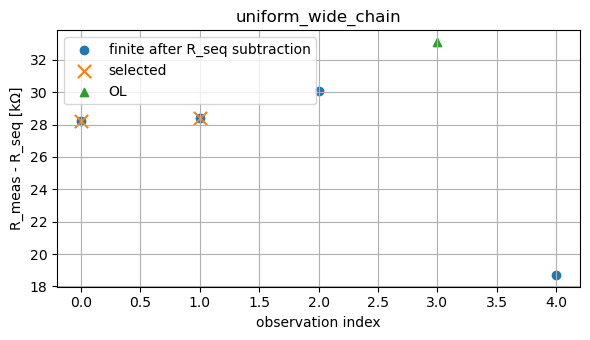

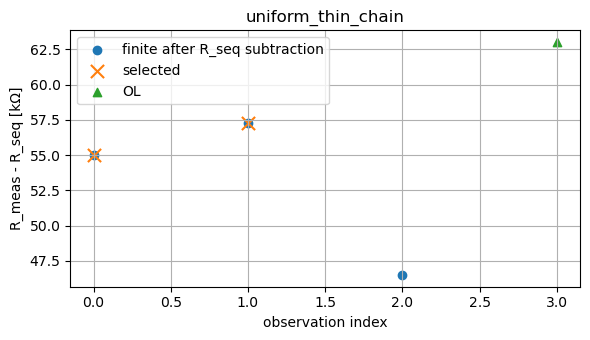

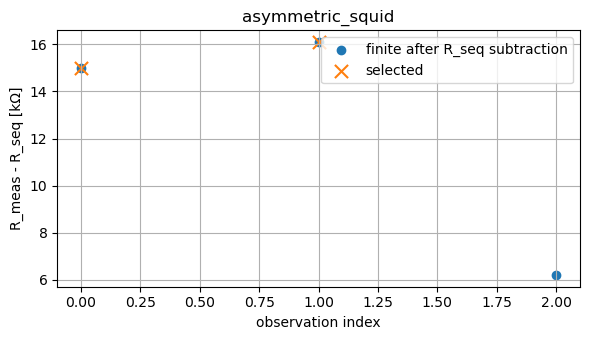

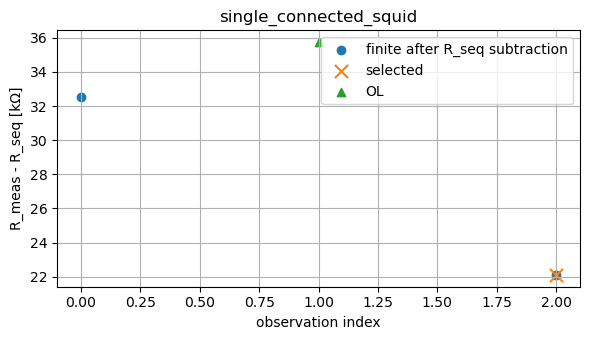

In [9]:
def plot_resistance_distribution(name: str, meta: Dict[str, Any]):
    df = meta["resistance_df"]
    finite = df[(~df["is_OL"]) & np.isfinite(df["R_net_ohm"])]
    selected = meta["selected_df"]

    plt.figure(figsize=(6, 3.5))
    if len(finite):
        plt.scatter(finite["idx"], finite["R_net_ohm"] / 1e3, label="finite after R_seq subtraction")
    if len(selected):
        plt.scatter(selected["idx"], selected["R_net_ohm"] / 1e3, s=90, marker="x", label="selected")
    ol = df[df["is_OL"]]
    if len(ol):
        ymax = (finite["R_net_ohm"].max() / 1e3 * 1.1) if len(finite) else 1.0
        plt.scatter(ol["idx"], np.full(len(ol), ymax), marker="^", label="OL")
    plt.title(name)
    plt.xlabel("observation index")
    plt.ylabel("R_meas - R_seq [kΩ]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, meta in metas.items():
    plot_resistance_distribution(name, meta)

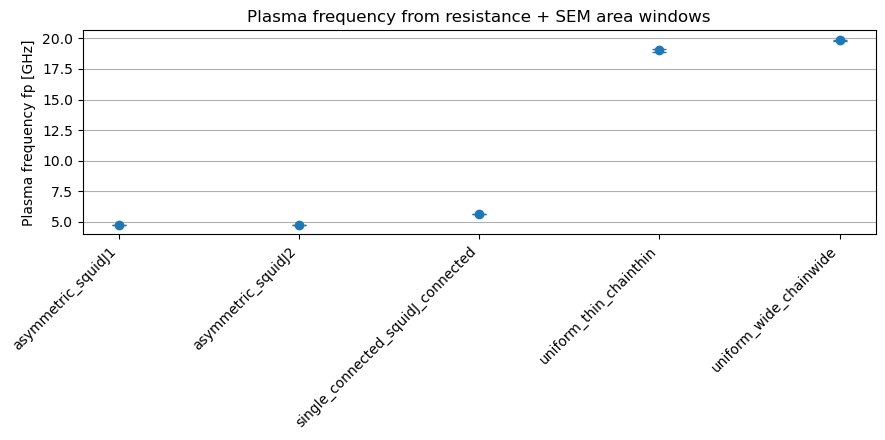

In [10]:
def plot_fp_windows(results: pd.DataFrame):
    if results.empty:
        print("No results to plot.")
        return
    plt.figure(figsize=(9, 4.5))
    labels, y, yerr_low, yerr_high = [], [], [], []

    for (structure, junction), g in results.groupby(["structure", "junction"]):
        gm = g[g["area_case"] == "area_mean"]
        gl = g[g["area_case"] == "area_low"]
        gh = g[g["area_case"] == "area_high"]
        if gm.empty:
            continue
        f_mean = gm["fp_GHz"].iloc[0]
        f_low = gl["fp_GHz"].iloc[0] if not gl.empty else f_mean
        f_high = gh["fp_GHz"].iloc[0] if not gh.empty else f_mean
        labels.append(f"{structure}{junction}")
        y.append(f_mean)
        yerr_low.append(abs(f_mean - f_low))
        yerr_high.append(abs(f_high - f_mean))

    x = np.arange(len(labels))
    plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt="o", capsize=5)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Plasma frequency fp [GHz]")
    plt.title("Plasma frequency from resistance + SEM area windows")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

plot_fp_windows(results)

## 6. Optional: compare all observations instead of selected median

This cell recalculates plausible plasma frequencies for every finite resistance observation. It is useful to see how much the result depends on `R_seq` and the resistance spread.


,structure,label,R_seq_ohm,R_net_ohm,Rn_ohm,fp_GHz
0,uniform_wide_chain,wide_A,100000.0,28200.0,1410.0,19.890004
1,uniform_wide_chain,wide_B,100000.0,28400.0,1420.0,19.819845
2,uniform_wide_chain,wide_C,100000.0,30100.0,1505.0,19.252015
3,uniform_wide_chain,wide_low_Rseq,10000.0,18700.0,935.0,24.425228
4,uniform_thin_chain,thin_A,100000.0,55000.0,2750.0,19.205706
5,uniform_thin_chain,thin_B,100000.0,57300.0,2865.0,18.816304
6,uniform_thin_chain,thin_low_Rseq,10000.0,46500.0,2325.0,20.887437


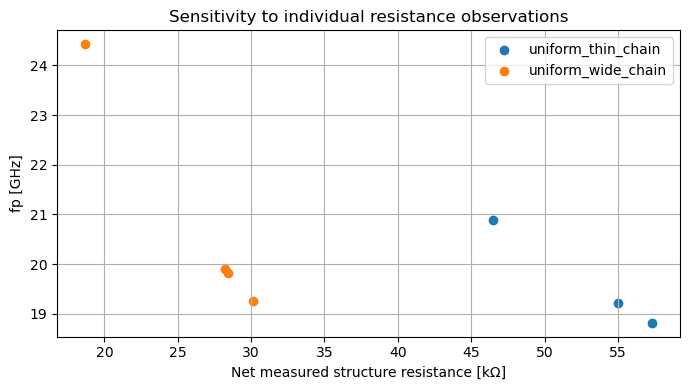

In [11]:
def all_observation_fp_for_uniform_chain(name, cfg, meta):
    if cfg["kind"] != "uniform_chain":
        return pd.DataFrame()
    N_j = int(cfg["junction_count"])
    sem_name = next(iter(cfg["sem"].keys()))
    st = sem_area_stats(cfg["sem"][sem_name], name=sem_name)
    area = st["area_mean_um2"]
    df = meta["resistance_df"]
    rows = []
    for _, r in df.iterrows():
        if r["is_OL"] or not np.isfinite(r["R_net_ohm"]) or r["R_net_ohm"] <= 0:
            continue
        Rn = r["R_net_ohm"] / N_j
        phys = plasma_freq_from_Rn_area(Rn, area)
        rows.append({"structure": name, "label": r["label"], "R_seq_ohm": r["R_seq_ohm"], "R_net_ohm": r["R_net_ohm"], **phys})
    return pd.DataFrame(rows)

obs_tables = []
for name, cfg in TEST_STRUCTURES.items():
    if cfg["kind"] == "uniform_chain":
        obs_tables.append(all_observation_fp_for_uniform_chain(name, cfg, metas[name]))
obs_fp = pd.concat(obs_tables, ignore_index=True) if obs_tables else pd.DataFrame()
if not obs_fp.empty:
    display(obs_fp[["structure", "label", "R_seq_ohm", "R_net_ohm", "Rn_ohm", "fp_GHz"]])
    plt.figure(figsize=(7,4))
    for structure, g in obs_fp.groupby("structure"):
        plt.scatter(g["R_net_ohm"]/1e3, g["fp_GHz"], label=structure)
    plt.xlabel("Net measured structure resistance [kΩ]")
    plt.ylabel("fp [GHz]")
    plt.title("Sensitivity to individual resistance observations")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No finite observation-level rows to display.")

## 7. Notes / next updates

When you provide the real data, update only `TEST_STRUCTURES`:

- replace dummy SEM `(width_um, length_um)` pairs,
- replace dummy resistance observations,
- set `junction_count` correctly for each chain,
- ensure units are correct (`kOhm`, `Ohm`, `MOhm` are supported),
- keep `OL` as a string for out-of-limit measurements.

Potential future improvements:

- add per-wafer / per-row grouping,
- add explicit dead-structure classifiers,
- estimate `Rn*A` distributions across multiple structures,
- export summary tables to CSV.
